# **Homework 1 Problem 1**

# **Marcus Brinkley | 801298280**

In [1]:
%load_ext tensorboard

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms, datasets
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch.nn.functional as F
import matplotlib.pyplot as plt

import datetime
import os
import tensorflow as tf

from tqdm import tqdm

In [4]:

from torchvision.transforms import v2

In [5]:
!pip install torchsummary

In [6]:
from torchsummary import summary

# **Problem 1A - Simplified Architecture**

In [7]:
# Define transformations for the training data
train_transform = v2.Compose([
    v2.Pad(padding=4, padding_mode='constant'),
    v2.RandomCrop(size=(32, 32)),
    v2.RandomHorizontalFlip(),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Define transformations for the test data (no augmentation)
test_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Define the batch size for training and testing
batch_size = 64

# Load the CIFAR-10 training dataset
trainset = torchvision.datasets.CIFAR10(root='./data',
                                        train=True,
                                        download=True,
                                        transform=train_transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

# Load the CIFAR-10 test dataset
testset = torchvision.datasets.CIFAR10(root='./data',
                                       train=False,
                                       download=True,
                                       transform=test_transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

# Define the class names for CIFAR-10
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:02<00:00, 70.7MB/s]


In [8]:
random_crop_transform = transforms.Compose([
    transforms.Pad(padding=4, padding_mode='constant'),
    transforms.RandomCrop(size=(32, 32)),
    transforms.ToTensor()
])

In [9]:
image_tensor = torch.rand(3, 32, 32) # Random 3-channel, 32x32 image
image_pil = transforms.ToPILImage()(image_tensor)

# 3. Apply the transformation
augmented_image = random_crop_transform(image_pil)


In [9]:
# Definition of AlexNet model class
class AlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
             # Conv Layer block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
             # Conv Layer block 2
            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
             # Conv Layer block 3
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
             # Conv Layer block 4
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
             # Conv Layer block 5
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Linear(256 * 1 * 1, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

num_classes = 10
model = AlexNet(num_classes=num_classes)

In [10]:
# Check if GPU is available and set the device accordingly
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
              ReLU-2           [-1, 64, 32, 32]               0
         MaxPool2d-3           [-1, 64, 16, 16]               0
            Conv2d-4          [-1, 192, 16, 16]         110,784
              ReLU-5          [-1, 192, 16, 16]               0
         MaxPool2d-6            [-1, 192, 8, 8]               0
            Conv2d-7            [-1, 384, 8, 8]         663,936
              ReLU-8            [-1, 384, 8, 8]               0
            Conv2d-9            [-1, 256, 8, 8]         884,992
             ReLU-10            [-1, 256, 8, 8]               0
           Conv2d-11            [-1, 256, 8, 8]         590,080
             ReLU-12            [-1, 256, 8, 8]               0
        MaxPool2d-13            [-1, 256, 4, 4]               0
AdaptiveAvgPool2d-14            [-1, 25

In [11]:
# Define the network, loss function, and optimizer
net = AlexNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)


In [12]:
# Lists for storing loss values and validation accuracy
train_loss_list = []
val_loss_list = []
val_accuracy_list = []


In [13]:
for epoch in range(30):  # loop over the dataset multiple times
    running_loss = 0.0
    net.train()  # Set the model to training mode
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss_list.append(running_loss / len(trainloader))

    # Validation loop
    running_loss = 0.0
    correct = 0
    total = 0
    net.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        for data in testloader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = net(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_loss_list.append(running_loss / len(testloader))
    val_accuracy = 100 * correct / total
    val_accuracy_list.append(val_accuracy)

    print(f'Epoch {epoch + 1}, Training loss: {train_loss_list[-1]}, Validation loss: {val_loss_list[-1]}, Validation Accuracy: {val_accuracy}%')

Epoch 1, Training loss: 2.3029121599538858, Validation loss: 2.302545620377656, Validation Accuracy: 10.0%
Epoch 2, Training loss: 2.302568177432965, Validation loss: 2.3023739757051893, Validation Accuracy: 10.0%
Epoch 3, Training loss: 2.302407545201919, Validation loss: 2.3021787534094162, Validation Accuracy: 10.0%
Epoch 4, Training loss: 2.3021614789353, Validation loss: 2.3018273153122824, Validation Accuracy: 11.96%
Epoch 5, Training loss: 2.301628680180406, Validation loss: 2.3009113415031677, Validation Accuracy: 14.44%
Epoch 6, Training loss: 2.299916673194417, Validation loss: 2.2974755262872977, Validation Accuracy: 16.78%
Epoch 7, Training loss: 2.289570555357677, Validation loss: 2.2667303009397664, Validation Accuracy: 17.31%
Epoch 8, Training loss: 2.142136678976171, Validation loss: 2.018438120556485, Validation Accuracy: 22.48%
Epoch 9, Training loss: 1.990367781018357, Validation loss: 1.918957228873186, Validation Accuracy: 23.54%
Epoch 10, Training loss: 1.92179625

In [14]:
first_layer = net.features[0]

In [15]:
#Obtains first convolutional layer
first_layer.weight

Parameter containing:
tensor([[[[-1.2676e-01,  9.6231e-02, -1.0533e-01],
          [-1.0190e-01,  2.3248e-02,  6.4776e-02],
          [-1.5861e-01, -1.9333e-02, -5.0779e-03]],

         [[-8.5569e-02,  1.1187e-01,  1.2764e-01],
          [-8.0145e-02,  1.7143e-01,  2.3440e-02],
          [-1.3687e-01, -7.8670e-02, -1.3896e-01]],

         [[ 2.3712e-02, -8.0283e-02,  1.5758e-01],
          [-1.8972e-01,  2.7194e-02,  1.2817e-01],
          [-1.0315e-01, -1.3050e-01, -8.0917e-02]]],


        [[[ 1.1962e-01, -1.0929e-01,  8.8652e-02],
          [-1.5828e-01, -4.4756e-02,  1.5355e-01],
          [-7.3757e-02,  1.5041e-01, -1.7949e-01]],

         [[-1.4584e-01,  1.5015e-02,  1.2732e-01],
          [-1.5956e-01,  2.5203e-02,  1.8236e-01],
          [ 9.9788e-02, -1.0009e-01, -1.5215e-01]],

         [[-6.5745e-02,  5.5255e-02, -5.8240e-02],
          [ 1.0303e-01, -9.4696e-02,  6.4535e-02],
          [-1.7554e-01,  4.1279e-02, -5.7172e-02]]],


        [[[ 3.1274e-02, -1.8166e-01, -7.5134

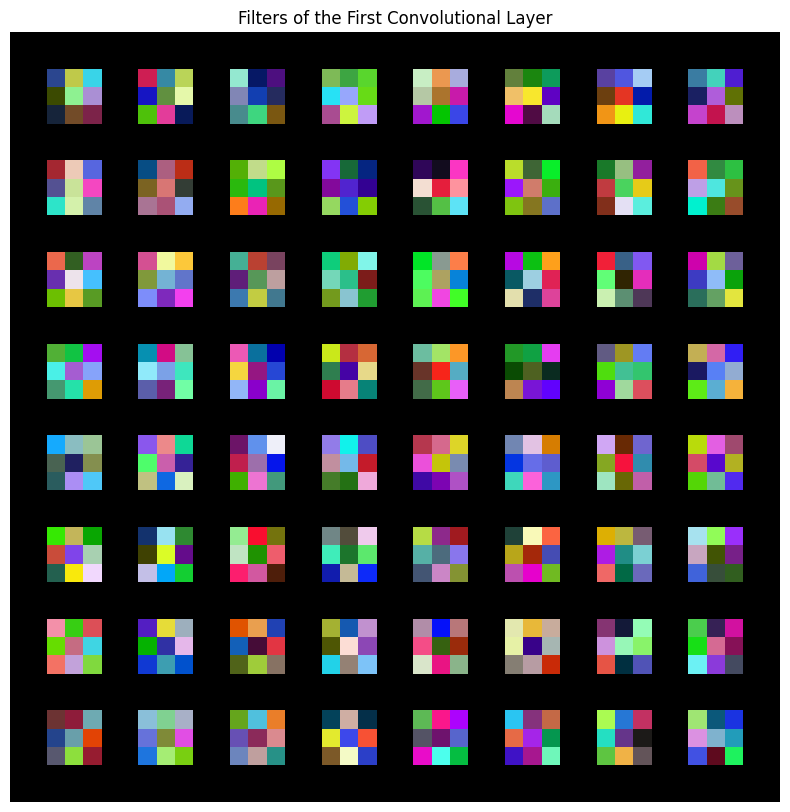

In [16]:
import torchvision.utils

# Get the weights of the first convolutional layer
weights = first_layer.weight.cpu().detach()

# Normalize weights to [0, 1] for visualization
# Reshape each filter to a 3-channel image (even if it's grayscale, to make make_grid work)
# If the filter has only one channel, duplicate it to 3 channels for display
if weights.shape[1] == 1:
    weights = weights.repeat(1, 3, 1, 1)

min_val = weights.min()
max_val = weights.max()
normalized_weights = (weights - min_val) / (max_val - min_val)

# Make a grid of images from the filters
grid_img = torchvision.utils.make_grid(normalized_weights, nrow=8, padding=2)

# Plot the grid
plt.figure(figsize=(10, 10))
plt.imshow(grid_img.permute(1, 2, 0))
plt.title('Filters of the First Convolutional Layer')
plt.axis('off')
plt.show()

In [17]:
# Print final validation accuracy
print(f'Final Validation Accuracy: {val_accuracy_list[-1]}%')
# Calculate total number of parameters
total_params = sum(p.numel() for p in net.parameters())
print(f'Total number of parameters in the model: {total_params}')

Final Validation Accuracy: 56.76%
Total number of parameters in the model: 2385738


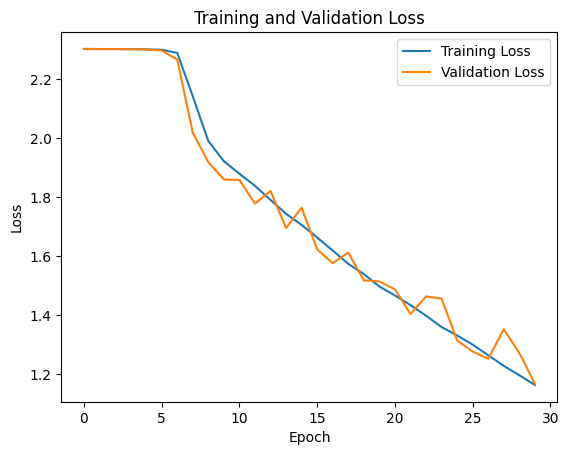

In [18]:
# Plotting training and validation loss
plt.plot(train_loss_list, label='Training Loss')
plt.plot(val_loss_list, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

### Validation Accuracy Curve

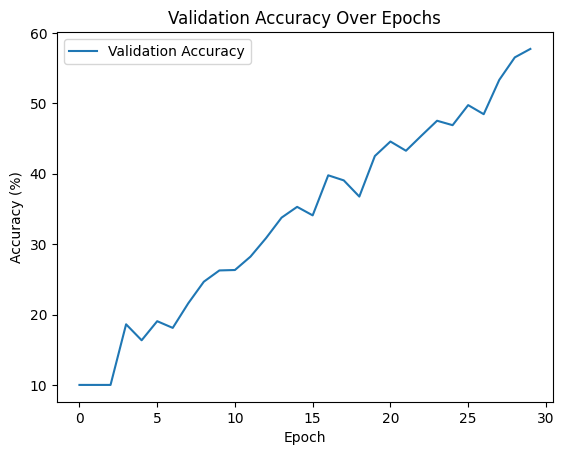

In [ ]:
plt.plot(val_accuracy_list, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy Over Epochs')
plt.legend()
plt.show()

### Confusion Matrix

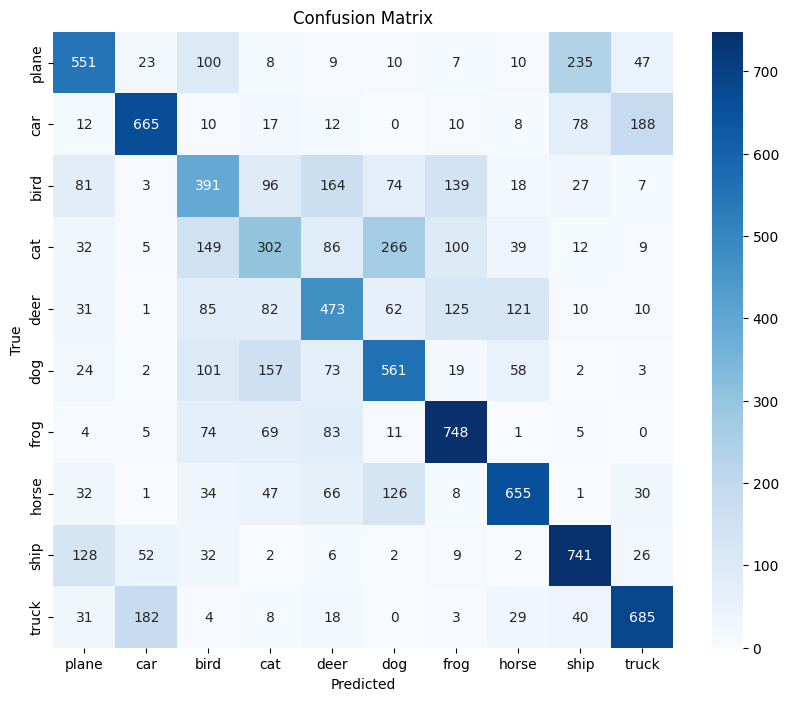

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_labels = []
all_predictions = []

net.eval()
with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# **Problem 1B - Dropout**

In [ ]:
# Definition of AlexNet model class with Dropout p= 0.5
class AlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1), # 32x32 -> 32x32
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # 32x32 -> 16x16

            nn.Conv2d(64, 192, kernel_size=3, padding=1), # 16x16 -> 16x16
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # 16x16 -> 8x8

            nn.Conv2d(192, 384, kernel_size=3, padding=1), # 8x8 -> 8x8
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, padding=1), # 8x8 -> 8x8
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1), # 8x8 -> 8x8
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # 8x8 -> 4x4
        )
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1)) # Reinstating the AdaptiveAvgPool2d
        self.classifier = nn.Sequential(
            nn.Linear(256 * 1 * 1, 256), # Output from avgpool is 256x1x1
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x) # Correctly using the avgpool layer
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

num_classes = 10
model = AlexNet(num_classes=num_classes)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
              ReLU-2           [-1, 64, 32, 32]               0
         MaxPool2d-3           [-1, 64, 16, 16]               0
            Conv2d-4          [-1, 192, 16, 16]         110,784
              ReLU-5          [-1, 192, 16, 16]               0
         MaxPool2d-6            [-1, 192, 8, 8]               0
            Conv2d-7            [-1, 384, 8, 8]         663,936
              ReLU-8            [-1, 384, 8, 8]               0
            Conv2d-9            [-1, 256, 8, 8]         884,992
             ReLU-10            [-1, 256, 8, 8]               0
           Conv2d-11            [-1, 256, 8, 8]         590,080
             ReLU-12            [-1, 256, 8, 8]               0
        MaxPool2d-13            [-1, 256, 4, 4]               0
AdaptiveAvgPool2d-14            [-1, 25

In [ ]:
# Define the network, loss function, and optimizer
net = AlexNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)


In [ ]:
# Lists for storing loss values and validation accuracy
train_loss_list = []
val_loss_list = []
val_accuracy_list = []


In [ ]:
for epoch in range(30):  # loop over the dataset multiple times
    running_loss = 0.0
    net.train()  # Set the model to training mode
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss_list.append(running_loss / len(trainloader))

    # Validation loop
    running_loss = 0.0
    correct = 0
    total = 0
    net.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        for data in testloader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = net(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_loss_list.append(running_loss / len(testloader))
    val_accuracy = 100 * correct / total
    val_accuracy_list.append(val_accuracy)

    print(f'Epoch {epoch + 1}, Training loss: {train_loss_list[-1]}, Validation loss: {val_loss_list[-1]}, Validation Accuracy: {val_accuracy}%')

Epoch 1, Training loss: 2.3030084801451935, Validation loss: 2.3025253305009974, Validation Accuracy: 10.0%
Epoch 2, Training loss: 2.3026204789081195, Validation loss: 2.3022930136152135, Validation Accuracy: 18.35%
Epoch 3, Training loss: 2.302240314995846, Validation loss: 2.3020138862026727, Validation Accuracy: 17.28%
Epoch 4, Training loss: 2.302065858145809, Validation loss: 2.3014743024376547, Validation Accuracy: 15.82%
Epoch 5, Training loss: 2.3012090906157825, Validation loss: 2.29989012791093, Validation Accuracy: 16.53%
Epoch 6, Training loss: 2.297846610588796, Validation loss: 2.2920556220279376, Validation Accuracy: 17.68%
Epoch 7, Training loss: 2.26494284298109, Validation loss: 2.151216468993266, Validation Accuracy: 18.33%
Epoch 8, Training loss: 2.09990250911859, Validation loss: 1.9991973395560199, Validation Accuracy: 22.1%
Epoch 9, Training loss: 2.0096687177562957, Validation loss: 1.9253750470033877, Validation Accuracy: 22.32%
Epoch 10, Training loss: 1.9507

In [ ]:
# Print final validation accuracy
print(f'Final Validation Accuracy: {val_accuracy_list[-1]}%')
# Calculate total number of parameters
total_params = sum(p.numel() for p in net.parameters())
print(f'Total number of parameters in the model: {total_params}')

Final Validation Accuracy: 47.48%
Total number of parameters in the model: 2385738


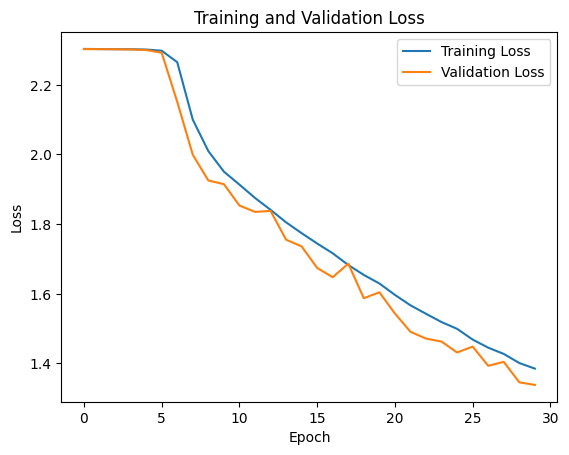

In [ ]:
# Plotting training and validation loss
plt.plot(train_loss_list, label='Training Loss')
plt.plot(val_loss_list, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

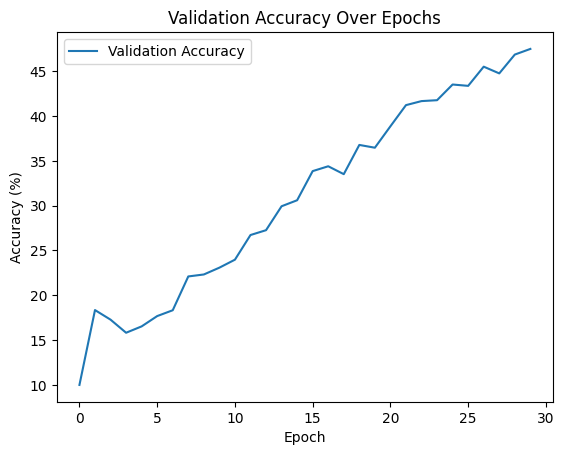

In [ ]:
plt.plot(val_accuracy_list, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy Over Epochs')
plt.legend()
plt.show()

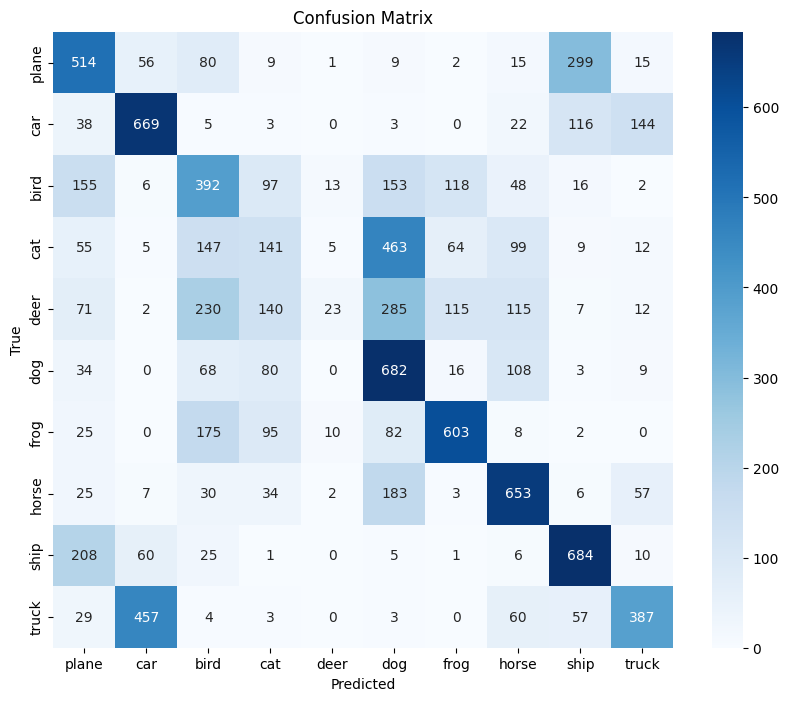

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_labels = []
all_predictions = []

net.eval()
with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Dropout of 30%

In [ ]:
# Definition of AlexNet model class with Dropout p= 0.3
class AlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Linear(256 * 1 * 1, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

num_classes = 10
model = AlexNet(num_classes=num_classes)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
              ReLU-2           [-1, 64, 32, 32]               0
         MaxPool2d-3           [-1, 64, 16, 16]               0
            Conv2d-4          [-1, 192, 16, 16]         110,784
              ReLU-5          [-1, 192, 16, 16]               0
         MaxPool2d-6            [-1, 192, 8, 8]               0
            Conv2d-7            [-1, 384, 8, 8]         663,936
              ReLU-8            [-1, 384, 8, 8]               0
            Conv2d-9            [-1, 256, 8, 8]         884,992
             ReLU-10            [-1, 256, 8, 8]               0
           Conv2d-11            [-1, 256, 8, 8]         590,080
             ReLU-12            [-1, 256, 8, 8]               0
        MaxPool2d-13            [-1, 256, 4, 4]               0
AdaptiveAvgPool2d-14            [-1, 25

In [ ]:
# Define the network, loss function, and optimizer
net = AlexNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)


In [ ]:
# Lists for storing loss values and validation accuracy
train_loss_list = []
val_loss_list = []
val_accuracy_list = []


In [ ]:
for epoch in range(30):  # loop over the dataset multiple times
    running_loss = 0.0
    net.train()  # Set the model to training mode
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss_list.append(running_loss / len(trainloader))

    # Validation loop
    running_loss = 0.0
    correct = 0
    total = 0
    net.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        for data in testloader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = net(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_loss_list.append(running_loss / len(testloader))
    val_accuracy = 100 * correct / total
    val_accuracy_list.append(val_accuracy)

    print(f'Epoch {epoch + 1}, Training loss: {train_loss_list[-1]}, Validation loss: {val_loss_list[-1]}, Validation Accuracy: {val_accuracy}%')

Epoch 1, Training loss: 2.303059207508936, Validation loss: 2.3026208513101953, Validation Accuracy: 10.0%
Epoch 2, Training loss: 2.302635116040554, Validation loss: 2.3023798663145416, Validation Accuracy: 9.95%
Epoch 3, Training loss: 2.302374004707922, Validation loss: 2.302096984948322, Validation Accuracy: 10.18%
Epoch 4, Training loss: 2.3020293971766597, Validation loss: 2.3015071814227257, Validation Accuracy: 10.01%
Epoch 5, Training loss: 2.3011731430697626, Validation loss: 2.299867713527315, Validation Accuracy: 16.06%
Epoch 6, Training loss: 2.2978578632140096, Validation loss: 2.292504175453429, Validation Accuracy: 17.69%
Epoch 7, Training loss: 2.262598899929115, Validation loss: 2.156324318260144, Validation Accuracy: 18.41%
Epoch 8, Training loss: 2.0847428119396003, Validation loss: 1.9891947226919187, Validation Accuracy: 22.47%
Epoch 9, Training loss: 1.987105147612979, Validation loss: 1.9158390266880108, Validation Accuracy: 23.72%
Epoch 10, Training loss: 1.930

In [ ]:
# Print final validation accuracy
print(f'Final Validation Accuracy: {val_accuracy_list[-1]}%')
# Calculate total number of parameters
total_params = sum(p.numel() for p in net.parameters())
print(f'Total number of parameters in the model: {total_params}')

Final Validation Accuracy: 51.22%
Total number of parameters in the model: 2385738


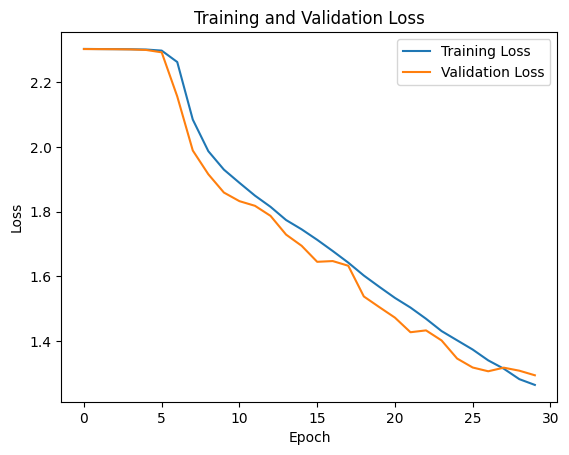

In [ ]:
# Plotting training and validation loss
plt.plot(train_loss_list, label='Training Loss')
plt.plot(val_loss_list, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

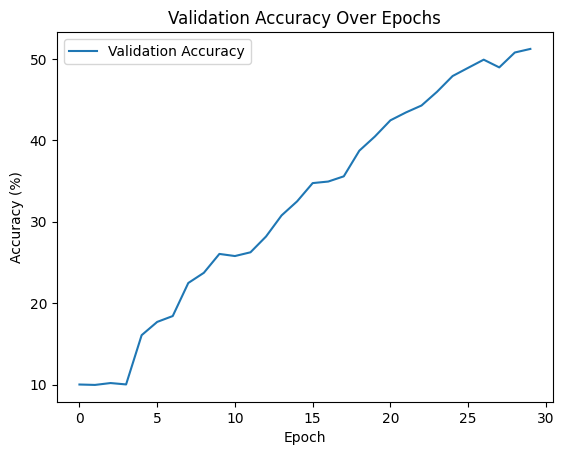

In [ ]:
plt.plot(val_accuracy_list, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy Over Epochs')
plt.legend()
plt.show()

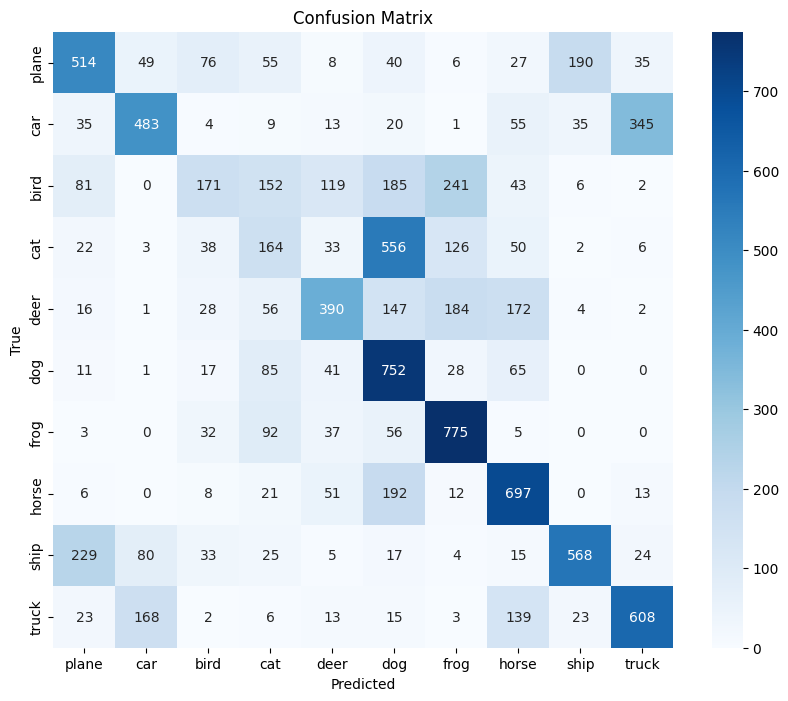

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_labels = []
all_predictions = []

net.eval()
with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## Problem 2 - Modified VGGNet on CIFAR-10

# Problem 2A : Modified VGGNet on CIFAR-10

In [ ]:
# Definition of VGGNet19 model class
class VGGNet19(nn.Module):
    def __init__(self, num_classes=10):
        super(VGGNet19, self).__init__()
        self.features = nn.Sequential(
           # Conv Layer block 1 (Desired final out_channels: 32)
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), # Add Batch Normalization
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer block 2 (Desired final out_channels: 64)
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), # Add Batch Normalization
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer block 3 (Desired final out_channels: 128)
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), # Add Batch Normalization
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer block 4 (Desired final out_channels: 160)
            nn.Conv2d(in_channels=128, out_channels=160, kernel_size=3, padding=1),
            nn.BatchNorm2d(160), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=160, out_channels=160, kernel_size=3, padding=1),
            nn.BatchNorm2d(160), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=160, out_channels=160, kernel_size=3, padding=1),
            nn.BatchNorm2d(160), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=160, out_channels=160, kernel_size=3, padding=1),
            nn.BatchNorm2d(160), # Add Batch Normalization
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer block 5 (Desired final out_channels: 160)
            nn.Conv2d(in_channels=160, out_channels=160, kernel_size=3, padding=1),
            nn.BatchNorm2d(160), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=160, out_channels=160, kernel_size=3, padding=1),
            nn.BatchNorm2d(160), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=160, out_channels=160, kernel_size=3, padding=1),
            nn.BatchNorm2d(160), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=160, out_channels=160, kernel_size=3, padding=1),
            nn.BatchNorm2d(160), # Add Batch Normalization
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Linear(160 * 1 * 1, 96),
            nn.ReLU(),
            nn.Linear(96, 96),
            nn.ReLU(),
            nn.Linear(96, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

num_classes = 10
model = VGGNet19(num_classes=num_classes)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
       BatchNorm2d-2           [-1, 32, 32, 32]              64
              ReLU-3           [-1, 32, 32, 32]               0
            Conv2d-4           [-1, 32, 32, 32]           9,248
       BatchNorm2d-5           [-1, 32, 32, 32]              64
              ReLU-6           [-1, 32, 32, 32]               0
         MaxPool2d-7           [-1, 32, 16, 16]               0
            Conv2d-8           [-1, 64, 16, 16]          18,496
       BatchNorm2d-9           [-1, 64, 16, 16]             128
             ReLU-10           [-1, 64, 16, 16]               0
           Conv2d-11           [-1, 64, 16, 16]          36,928
      BatchNorm2d-12           [-1, 64, 16, 16]             128
             ReLU-13           [-1, 64, 16, 16]               0
        MaxPool2d-14             [-1, 6

In [ ]:
# Define the network, loss function, and optimizer
net = VGGNet19().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)


In [ ]:
# Lists for storing loss values and validation accuracy
train_loss_list = []
val_loss_list = []
val_accuracy_list = []


In [ ]:
for epoch in range(30):  # loop over the dataset multiple times
    running_loss = 0.0
    net.train()  # Set the model to training mode
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss_list.append(running_loss / len(trainloader))

    # Validation loop
    running_loss = 0.0
    correct = 0
    total = 0
    net.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        for data in testloader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = net(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_loss_list.append(running_loss / len(testloader))
    val_accuracy = 100 * correct / total
    val_accuracy_list.append(val_accuracy)

    print(f'Epoch {epoch + 1}, Training loss: {train_loss_list[-1]}, Validation loss: {val_loss_list[-1]}, Validation Accuracy: {val_accuracy}%')

Epoch 1, Training loss: 1.739308471417488, Validation loss: 1.3290032922841941, Validation Accuracy: 51.36%
Epoch 2, Training loss: 1.199055927183927, Validation loss: 1.1173021493444018, Validation Accuracy: 60.75%
Epoch 3, Training loss: 0.9665186312192541, Validation loss: 0.964328536941747, Validation Accuracy: 66.82%
Epoch 4, Training loss: 0.8331531832361465, Validation loss: 0.8022627293304273, Validation Accuracy: 72.4%
Epoch 5, Training loss: 0.7353751746284992, Validation loss: 0.6912469888568684, Validation Accuracy: 76.94%
Epoch 6, Training loss: 0.6712692563643541, Validation loss: 0.6731716253954894, Validation Accuracy: 76.47%
Epoch 7, Training loss: 0.6194594624402273, Validation loss: 0.6130207661230853, Validation Accuracy: 78.69%
Epoch 8, Training loss: 0.5766242993876453, Validation loss: 0.609425861364717, Validation Accuracy: 78.62%
Epoch 9, Training loss: 0.5422481359804378, Validation loss: 0.5470013835817386, Validation Accuracy: 81.11%
Epoch 10, Training loss:

In [ ]:
# Print final validation accuracy
print(f'Final Validation Accuracy: {val_accuracy_list[-1]}%')
# Calculate total number of parameters
total_params = sum(p.numel() for p in net.parameters())
print(f'Total number of parameters in the model: {total_params}')

Final Validation Accuracy: 86.46%
Total number of parameters in the model: 2410282


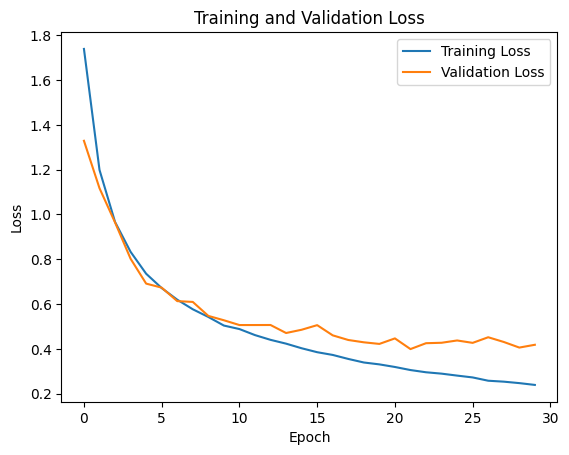

In [ ]:
# Plotting training and validation loss
plt.plot(train_loss_list, label='Training Loss')
plt.plot(val_loss_list, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

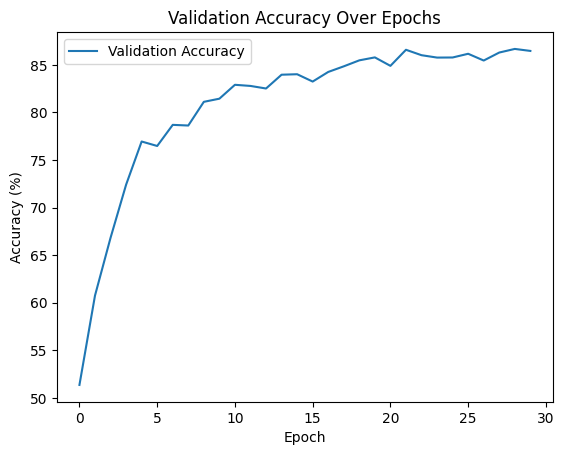

In [ ]:
plt.plot(val_accuracy_list, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy Over Epochs')
plt.legend()
plt.show()

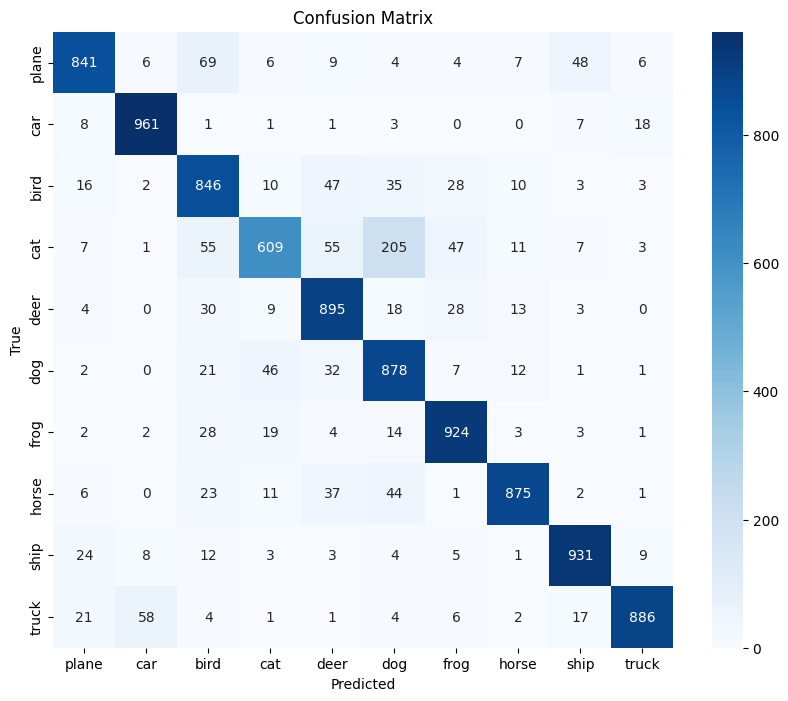

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_labels = []
all_predictions = []

net.eval()
with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Problem 2B: Dropout and Cross-Model Comparison

In [ ]:
# Definition of VGGNet19 model class with dropout p=0.5
class VGGNet19(nn.Module):
    def __init__(self, num_classes=10):
        super(VGGNet19, self).__init__()
        self.features = nn.Sequential(
           # Conv Layer block 1 (Desired final out_channels: 32)
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), # Add Batch Normalization
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer block 2 (Desired final out_channels: 64)
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), # Add Batch Normalization
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer block 3 (Desired final out_channels: 128)
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), # Add Batch Normalization
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer block 4 (Desired final out_channels: 160)
            nn.Conv2d(in_channels=128, out_channels=160, kernel_size=3, padding=1),
            nn.BatchNorm2d(160), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=160, out_channels=160, kernel_size=3, padding=1),
            nn.BatchNorm2d(160), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=160, out_channels=160, kernel_size=3, padding=1),
            nn.BatchNorm2d(160), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=160, out_channels=160, kernel_size=3, padding=1),
            nn.BatchNorm2d(160), # Add Batch Normalization
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer block 5 (Desired final out_channels: 160)
            nn.Conv2d(in_channels=160, out_channels=160, kernel_size=3, padding=1),
            nn.BatchNorm2d(160), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=160, out_channels=160, kernel_size=3, padding=1),
            nn.BatchNorm2d(160), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=160, out_channels=160, kernel_size=3, padding=1),
            nn.BatchNorm2d(160), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=160, out_channels=160, kernel_size=3, padding=1),
            nn.BatchNorm2d(160), # Add Batch Normalization
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Linear(160 * 1 * 1, 96),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(96, 96),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(96, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten the tensor
        x = self.classifier(x)
        return x

num_classes = 10
model = VGGNet19(num_classes=num_classes)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
       BatchNorm2d-2           [-1, 32, 32, 32]              64
              ReLU-3           [-1, 32, 32, 32]               0
            Conv2d-4           [-1, 32, 32, 32]           9,248
       BatchNorm2d-5           [-1, 32, 32, 32]              64
              ReLU-6           [-1, 32, 32, 32]               0
         MaxPool2d-7           [-1, 32, 16, 16]               0
            Conv2d-8           [-1, 64, 16, 16]          18,496
       BatchNorm2d-9           [-1, 64, 16, 16]             128
             ReLU-10           [-1, 64, 16, 16]               0
           Conv2d-11           [-1, 64, 16, 16]          36,928
      BatchNorm2d-12           [-1, 64, 16, 16]             128
             ReLU-13           [-1, 64, 16, 16]               0
        MaxPool2d-14             [-1, 6

In [ ]:
net = VGGNet19().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)


In [ ]:
# Lists for storing loss values and validation accuracy
train_loss_list = []
val_loss_list = []
val_accuracy_list = []


In [ ]:
for epoch in range(30):  # loop over the dataset multiple times
    running_loss = 0.0
    net.train()  # Set the model to training mode
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss_list.append(running_loss / len(trainloader))

    # Validation loop
    running_loss = 0.0
    correct = 0
    total = 0
    net.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        for data in testloader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = net(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_loss_list.append(running_loss / len(testloader))
    val_accuracy = 100 * correct / total
    val_accuracy_list.append(val_accuracy)

    print(f'Epoch {epoch + 1}, Training loss: {train_loss_list[-1]}, Validation loss: {val_loss_list[-1]}, Validation Accuracy: {val_accuracy}%')

Epoch 1, Training loss: 1.9651987793500467, Validation loss: 1.5856450302585674, Validation Accuracy: 40.1%
Epoch 2, Training loss: 1.566638019993482, Validation loss: 1.4743537280210264, Validation Accuracy: 46.77%
Epoch 3, Training loss: 1.3203362189138028, Validation loss: 1.060294204456791, Validation Accuracy: 62.53%
Epoch 4, Training loss: 1.155257080445814, Validation loss: 0.960795734718347, Validation Accuracy: 66.68%
Epoch 5, Training loss: 1.027480500738334, Validation loss: 0.8421340501232512, Validation Accuracy: 71.15%
Epoch 6, Training loss: 0.9417125077351279, Validation loss: 0.8060786050216407, Validation Accuracy: 73.22%
Epoch 7, Training loss: 0.876678351779728, Validation loss: 0.7670677243524296, Validation Accuracy: 73.9%
Epoch 8, Training loss: 0.8191881231639696, Validation loss: 0.7562825127392058, Validation Accuracy: 75.99%
Epoch 9, Training loss: 0.7801507589838389, Validation loss: 0.6624882471789221, Validation Accuracy: 77.77%
Epoch 10, Training loss: 0.

In [ ]:
# Print final validation accuracy
print(f'Final Validation Accuracy: {val_accuracy_list[-1]}%')
# Calculate total number of parameters
total_params = sum(p.numel() for p in net.parameters())
print(f'Total number of parameters in the model: {total_params}')

Final Validation Accuracy: 85.18%
Total number of parameters in the model: 2410282


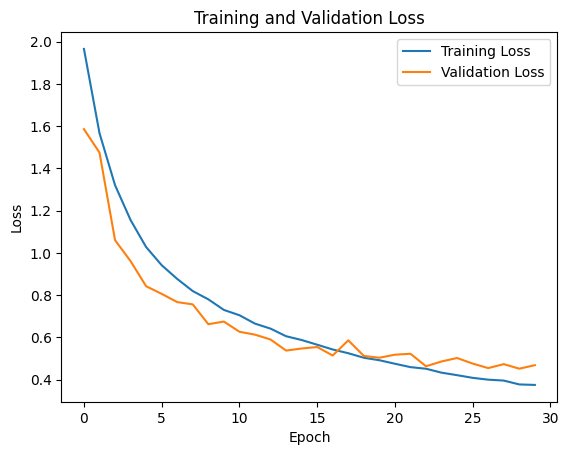

In [ ]:
# Plotting training and validation loss
plt.plot(train_loss_list, label='Training Loss')
plt.plot(val_loss_list, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

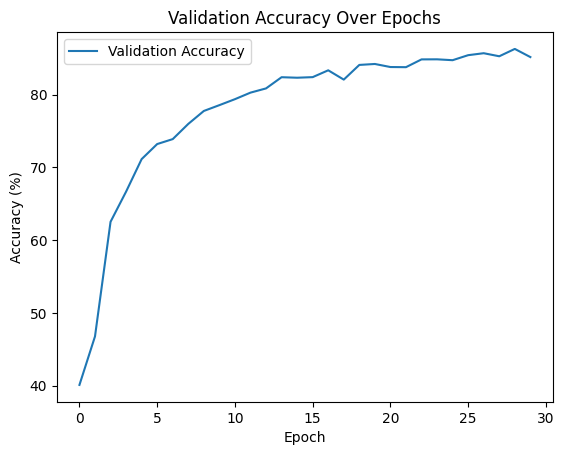

In [ ]:
plt.plot(val_accuracy_list, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy Over Epochs')
plt.legend()
plt.show()

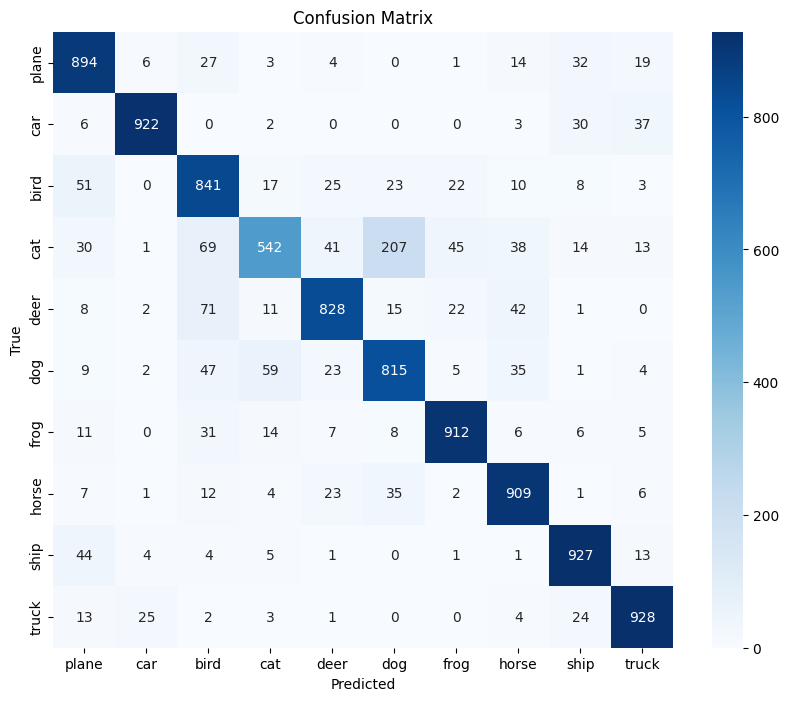

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_labels = []
all_predictions = []

net.eval() # Set model to evaluation mode
with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = net(images) # Use 'net' instead of 'model'
        _, predicted = torch.max(outputs.data, 1)
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# P= 30%

In [ ]:
# Definition of VGGNet19 model class with dropout p=0.3
class VGGNet19(nn.Module):
    def __init__(self, num_classes=10):
        super(VGGNet19, self).__init__()
        self.features = nn.Sequential(
           # Conv Layer block 1 (Desired final out_channels: 32)
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), # Add Batch Normalization
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer block 2 (Desired final out_channels: 64)
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), # Add Batch Normalization
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer block 3 (Desired final out_channels: 128)
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), # Add Batch Normalization
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer block 4 (Desired final out_channels: 160)
            nn.Conv2d(in_channels=128, out_channels=160, kernel_size=3, padding=1),
            nn.BatchNorm2d(160), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=160, out_channels=160, kernel_size=3, padding=1),
            nn.BatchNorm2d(160), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=160, out_channels=160, kernel_size=3, padding=1),
            nn.BatchNorm2d(160), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=160, out_channels=160, kernel_size=3, padding=1),
            nn.BatchNorm2d(160), # Add Batch Normalization
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer block 5 (Desired final out_channels: 160)
            nn.Conv2d(in_channels=160, out_channels=160, kernel_size=3, padding=1),
            nn.BatchNorm2d(160), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=160, out_channels=160, kernel_size=3, padding=1),
            nn.BatchNorm2d(160), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=160, out_channels=160, kernel_size=3, padding=1),
            nn.BatchNorm2d(160), # Add Batch Normalization
            nn.ReLU(),
            nn.Conv2d(in_channels=160, out_channels=160, kernel_size=3, padding=1),
            nn.BatchNorm2d(160), # Add Batch Normalization
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Linear(160 * 1 * 1, 96),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(96, 96),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(96, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

num_classes = 10
model = VGGNet19(num_classes=num_classes)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
       BatchNorm2d-2           [-1, 32, 32, 32]              64
              ReLU-3           [-1, 32, 32, 32]               0
            Conv2d-4           [-1, 32, 32, 32]           9,248
       BatchNorm2d-5           [-1, 32, 32, 32]              64
              ReLU-6           [-1, 32, 32, 32]               0
         MaxPool2d-7           [-1, 32, 16, 16]               0
            Conv2d-8           [-1, 64, 16, 16]          18,496
       BatchNorm2d-9           [-1, 64, 16, 16]             128
             ReLU-10           [-1, 64, 16, 16]               0
           Conv2d-11           [-1, 64, 16, 16]          36,928
      BatchNorm2d-12           [-1, 64, 16, 16]             128
             ReLU-13           [-1, 64, 16, 16]               0
        MaxPool2d-14             [-1, 6

In [ ]:
net = VGGNet19().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)


In [ ]:
# Lists for storing loss values and validation accuracy
train_loss_list = []
val_loss_list = []
val_accuracy_list = []


In [ ]:
for epoch in range(30):  # loop over the dataset multiple times
    running_loss = 0.0
    net.train()  # Set the model to training mode
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss_list.append(running_loss / len(trainloader))

    # Validation loop
    running_loss = 0.0
    correct = 0
    total = 0
    net.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        for data in testloader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = net(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_loss_list.append(running_loss / len(testloader))
    val_accuracy = 100 * correct / total
    val_accuracy_list.append(val_accuracy)

    print(f'Epoch {epoch + 1}, Training loss: {train_loss_list[-1]}, Validation loss: {val_loss_list[-1]}, Validation Accuracy: {val_accuracy}%')

# Problem 3 - ResNet-11 vs. ResNet-18 on CIFAR-10

# Problem 3A - ResNet-18 Implementation

In [12]:
class BasicBlock(nn.Module):
    expansion = 1  # Expansion factor to adjust the number of output channels if needed

    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        # First convolutional layer of the block
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)  # Batch normalization after the first convolution

        # Second convolutional layer of the block
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)  # Batch normalization after the second convolution

        # Shortcut connection to match input and output dimensions if necessary
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != self.expansion * out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, self.expansion * out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * out_channels)
            )

    def forward(self, x):
        # Forward pass through the first convolution, batch norm, and ReLU activation
        out = F.relu(self.bn1(self.conv1(x)))
        # Forward pass through the second convolution and batch norm
        out = self.bn2(self.conv2(out))
        # Adding the shortcut connection's output to the main path's output
        out += self.shortcut(x)
        # Final ReLU activation after adding the shortcut
        out = F.relu(out)
        return out

In [ ]:
class ResNet18(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet18, self).__init__()
        self.in_channels = 64  # Initial number of input channels

        # Initial convolutional layer before entering the residual blocks
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)  # Batch normalization after the initial convolution

        # Creating layers of blocks with increasing channel sizes
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        # Final fully connected layer for classification
        self.linear = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        # Helper function to create a layer with specified blocks
        strides = [stride] + [1]*(num_blocks-1)  # First block could have a stride and the rest have stride of 1
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels * block.expansion  # Update in_channels for the next block
        return nn.Sequential(*layers)

    def forward(self, x):
        # Forward pass through the initial convolution, batch norm, and ReLU activation
        out = F.relu(self.bn1(self.conv1(x)))
        # Forward pass through all the layers of blocks
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        # Global average pooling before the final layer
        out = F.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)  # Flatten the output for the fully connected layer
        out = self.linear(out)  # Final classification layer
        return out

In [ ]:
model = ResNet18(BasicBlock, [2, 2, 2, 2], num_classes=10)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,728
       BatchNorm2d-2           [-1, 64, 32, 32]             128
            Conv2d-3           [-1, 64, 32, 32]          36,864
       BatchNorm2d-4           [-1, 64, 32, 32]             128
            Conv2d-5           [-1, 64, 32, 32]          36,864
       BatchNorm2d-6           [-1, 64, 32, 32]             128
        BasicBlock-7           [-1, 64, 32, 32]               0
            Conv2d-8           [-1, 64, 32, 32]          36,864
       BatchNorm2d-9           [-1, 64, 32, 32]             128
           Conv2d-10           [-1, 64, 32, 32]          36,864
      BatchNorm2d-11           [-1, 64, 32, 32]             128
       BasicBlock-12           [-1, 64, 32, 32]               0
           Conv2d-13          [-1, 128, 16, 16]          73,728
      BatchNorm2d-14          [-1, 128,

In [ ]:
net = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)


In [ ]:
# Lists for storing loss values and validation accuracy
train_loss_list = []
val_loss_list = []
val_accuracy_list = []

In [ ]:
for epoch in range(50):  # loop over the dataset multiple times
    running_loss = 0.0
    net.train()  # Set the model to training mode
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss_list.append(running_loss / len(trainloader))

    scheduler.step() # Call scheduler.step() after each epoch

    # Validation loop
    running_loss = 0.0
    correct = 0
    total = 0
    net.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        for data in testloader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = net(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_loss_list.append(running_loss / len(testloader))
    val_accuracy = 100 * correct / total
    val_accuracy_list.append(val_accuracy)

    print(f'Epoch {epoch + 1}, Training loss: {train_loss_list[-1]}, Validation loss: {val_loss_list[-1]}, Validation Accuracy: {val_accuracy}%')

Epoch 1, Training loss: 1.4793105017193748, Validation loss: 1.245291880741241, Validation Accuracy: 56.5%
Epoch 2, Training loss: 1.0236908176061137, Validation loss: 0.9639656376686825, Validation Accuracy: 66.13%
Epoch 3, Training loss: 0.8198864134147649, Validation loss: 0.7755508508272232, Validation Accuracy: 73.21%
Epoch 4, Training loss: 0.6940002483327675, Validation loss: 0.8078927262953133, Validation Accuracy: 73.51%
Epoch 5, Training loss: 0.6116660312008675, Validation loss: 0.6926699779975186, Validation Accuracy: 75.89%
Epoch 6, Training loss: 0.5504631669739323, Validation loss: 0.6227805022221462, Validation Accuracy: 78.91%
Epoch 7, Training loss: 0.49526295976718065, Validation loss: 0.5312068858154261, Validation Accuracy: 81.95%
Epoch 8, Training loss: 0.4573339830769602, Validation loss: 0.5520329951860343, Validation Accuracy: 81.76%
Epoch 9, Training loss: 0.424767035009611, Validation loss: 0.48956716734512595, Validation Accuracy: 84.01%
Epoch 10, Training l

In [ ]:
# Print final validation accuracy
print(f'Final Validation Accuracy: {val_accuracy_list[-1]}%')
# Calculate total number of parameters
total_params = sum(p.numel() for p in net.parameters())
print(f'Total number of parameters in the model: {total_params}')

Final Validation Accuracy: 91.04%
Total number of parameters in the model: 11173962


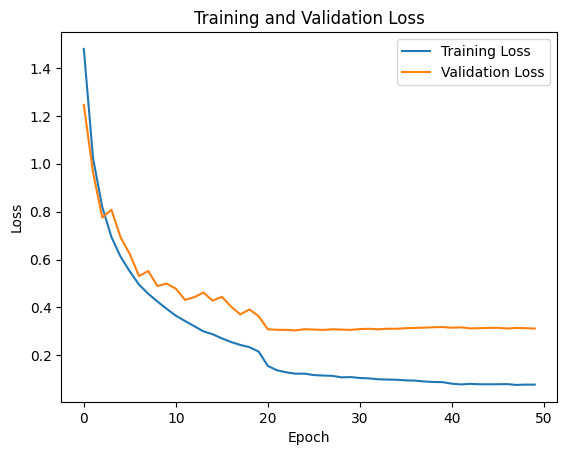

In [ ]:
# Plotting training and validation loss
plt.plot(train_loss_list, label='Training Loss')
plt.plot(val_loss_list, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

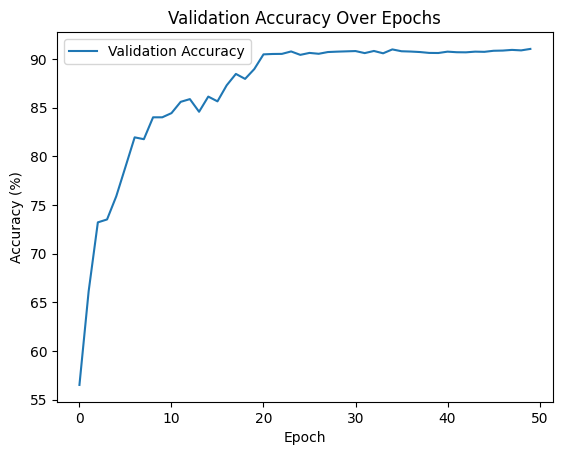

In [ ]:
plt.plot(val_accuracy_list, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy Over Epochs')
plt.legend()
plt.show()

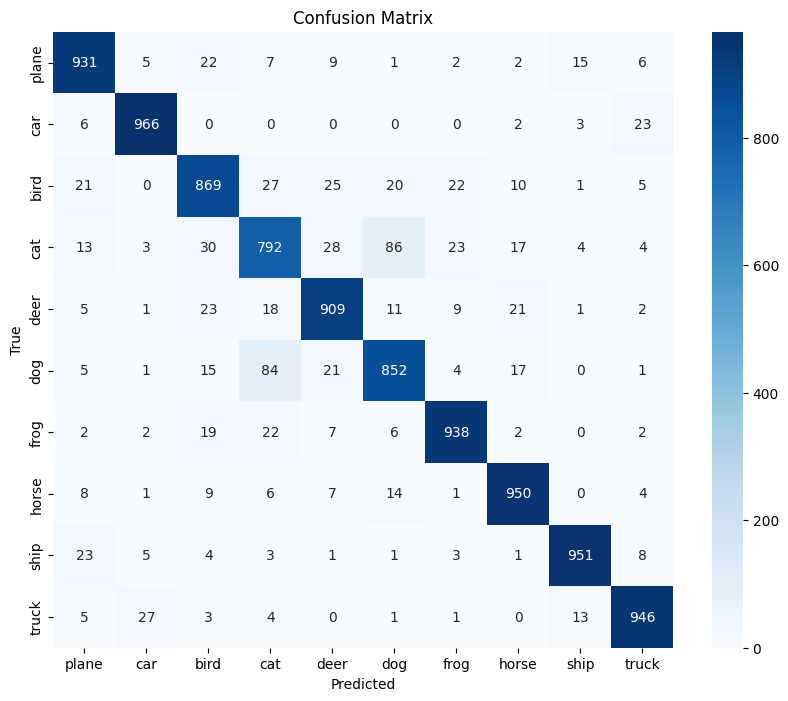

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_labels = []
all_predictions = []

net.eval() # Set model to evaluation mode
with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = net(images) # Use 'net' instead of 'model'
        _, predicted = torch.max(outputs.data, 1)
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Problem 3B -  Dropout and Final Comparison

Change the rate of the dropout within the code for both ResNets

In [ ]:
class ResNet18(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet18, self).__init__()
        self.in_channels = 64  # Initial number of input channels

        # Initial convolutional layer before entering the residual blocks
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)  # Batch normalization after the initial convolution

        # Creating layers of blocks with increasing channel sizes
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        # Dropout layer added here after feature extraction
        self.dropout = nn.Dropout(p=0.3)

        # Final fully connected layer for classification
        self.linear = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        # Helper function to create a layer with specified blocks
        strides = [stride] + [1]*(num_blocks-1)  # First block could have a stride and the rest have stride of 1
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels * block.expansion  # Update in_channels for the next block
        return nn.Sequential(*layers)

    def forward(self, x):
        # Forward pass through the initial convolution, batch norm, and ReLU activation
        out = F.relu(self.bn1(self.conv1(x)))
        # Forward pass through all the layers of blocks
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        # Global average pooling before the final layer
        out = F.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)  # Flatten the output for the fully connected layer
        # dropout before the final linear layer
        out = self.dropout(out)
        out = self.linear(out)  # Final classification layer
        return out

In [ ]:
model = ResNet18(BasicBlock, [2, 2, 2, 2], num_classes=10)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,728
       BatchNorm2d-2           [-1, 64, 32, 32]             128
            Conv2d-3           [-1, 64, 32, 32]          36,864
       BatchNorm2d-4           [-1, 64, 32, 32]             128
            Conv2d-5           [-1, 64, 32, 32]          36,864
       BatchNorm2d-6           [-1, 64, 32, 32]             128
        BasicBlock-7           [-1, 64, 32, 32]               0
            Conv2d-8           [-1, 64, 32, 32]          36,864
       BatchNorm2d-9           [-1, 64, 32, 32]             128
           Conv2d-10           [-1, 64, 32, 32]          36,864
      BatchNorm2d-11           [-1, 64, 32, 32]             128
       BasicBlock-12           [-1, 64, 32, 32]               0
           Conv2d-13          [-1, 128, 16, 16]          73,728
      BatchNorm2d-14          [-1, 128,

In [ ]:
net = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)


In [ ]:
# Lists for storing loss values and validation accuracy
train_loss_list = []
val_loss_list = []
val_accuracy_list = []

In [ ]:
for epoch in range(50):  # loop over the dataset multiple times
    running_loss = 0.0
    net.train()  # Set the model to training mode
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss_list.append(running_loss / len(trainloader))

    scheduler.step() # Call scheduler.step() after each epoch

    # Validation loop
    running_loss = 0.0
    correct = 0
    total = 0
    net.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        for data in testloader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = net(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_loss_list.append(running_loss / len(testloader))
    val_accuracy = 100 * correct / total
    val_accuracy_list.append(val_accuracy)

    print(f'Epoch {epoch + 1}, Training loss: {train_loss_list[-1]}, Validation loss: {val_loss_list[-1]}, Validation Accuracy: {val_accuracy}%')

Epoch 1, Training loss: 1.5935864440925287, Validation loss: 1.3238123465495504, Validation Accuracy: 53.42%
Epoch 2, Training loss: 1.1177137812690052, Validation loss: 0.9752035528231578, Validation Accuracy: 64.81%
Epoch 3, Training loss: 0.9026937958072213, Validation loss: 0.8588169965015096, Validation Accuracy: 69.96%
Epoch 4, Training loss: 0.7581654846515802, Validation loss: 0.739449048687698, Validation Accuracy: 75.14%
Epoch 5, Training loss: 0.6644692837887103, Validation loss: 0.615512309939998, Validation Accuracy: 78.63%
Epoch 6, Training loss: 0.5962503460209693, Validation loss: 0.5859696501569384, Validation Accuracy: 80.19%
Epoch 7, Training loss: 0.5483927957313445, Validation loss: 0.6077509611655193, Validation Accuracy: 79.92%
Epoch 8, Training loss: 0.5033912027011747, Validation loss: 0.5115240399435068, Validation Accuracy: 82.62%
Epoch 9, Training loss: 0.46586747076886387, Validation loss: 0.5037628230015943, Validation Accuracy: 82.84%
Epoch 10, Training l

In [ ]:
# Print final validation accuracy
print(f'Final Validation Accuracy: {val_accuracy_list[-1]}%')
# Calculate total number of parameters
total_params = sum(p.numel() for p in net.parameters())
print(f'Total number of parameters in the model: {total_params}')

Final Validation Accuracy: 90.82%
Total number of parameters in the model: 11173962


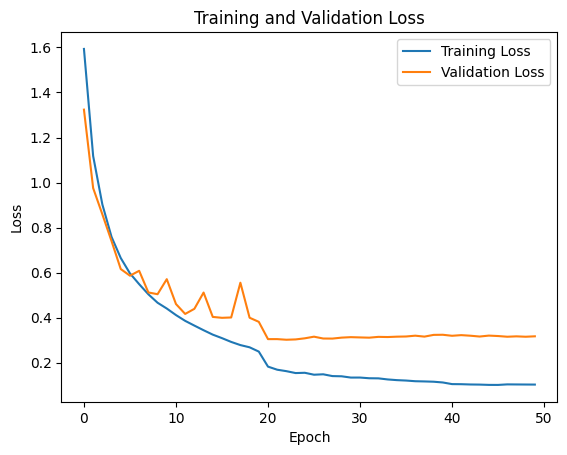

In [ ]:
# Plotting training and validation loss
plt.plot(train_loss_list, label='Training Loss')
plt.plot(val_loss_list, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

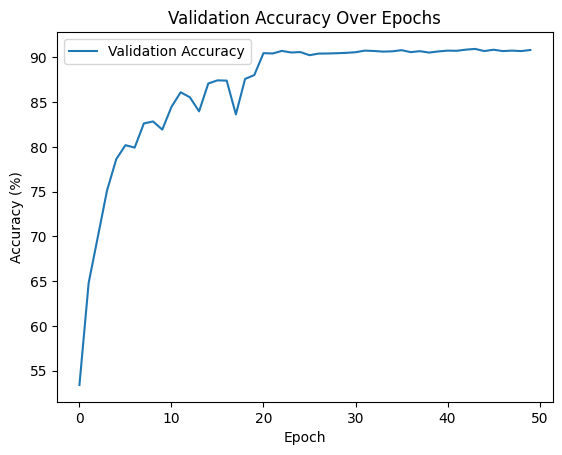

In [ ]:
plt.plot(val_accuracy_list, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy Over Epochs')
plt.legend()
plt.show()

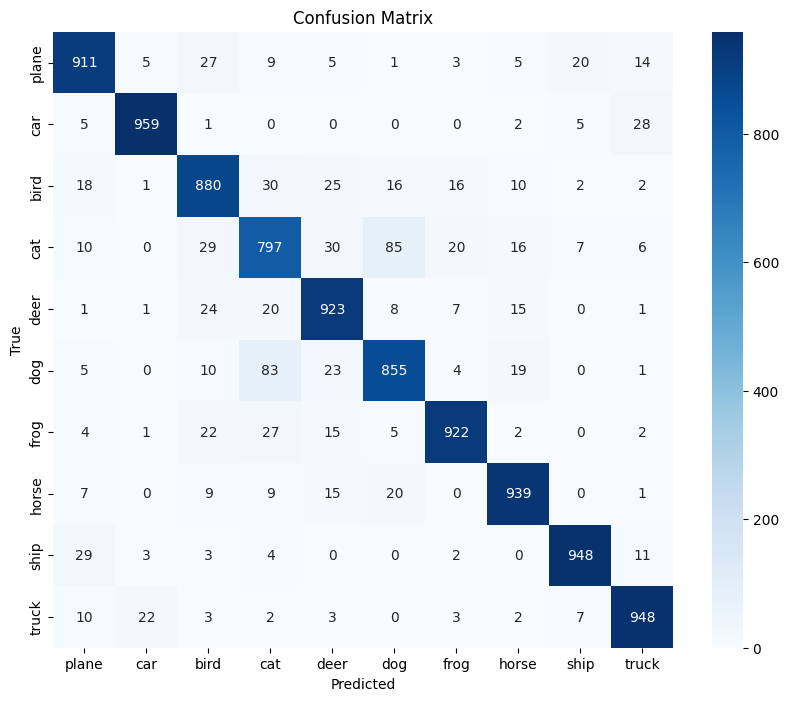

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_labels = []
all_predictions = []

net.eval() # Set model to evaluation mode
with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = net(images) # Use 'net' instead of 'model'
        _, predicted = torch.max(outputs.data, 1)
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# **ResNet11 Dropout:**

In [10]:
class ResNet11(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet11, self).__init__()
        self.in_channels = 64  # Initial number of input channels

        # Initial convolutional layer before entering the residual blocks
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)  # Batch normalization after the initial convolution

        # Creating layers of blocks with increasing channel sizes
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

         # Dropout layer added here after feature extraction
        self.dropout = nn.Dropout(p=0.3)


        # Final fully connected layer for classification
        self.linear = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        # Helper function to create a layer with specified blocks
        strides = [stride] + [1]*(num_blocks-1)  # First block could have a stride and the rest have stride of 1
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels * block.expansion  # Update in_channels for the next block
        return nn.Sequential(*layers)

    def forward(self, x):
        # Forward pass through the initial convolution, batch norm, and ReLU activation
        out = F.relu(self.bn1(self.conv1(x)))
        # Forward pass through all the layers of blocks
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        # Global average pooling before the final layer
        out = F.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)  # Flatten the output for the fully connected layer
        # Apply dropout
        out = self.dropout(out)
        out = self.linear(out)  # Final classification layer
        return out

In [13]:
model = ResNet11(BasicBlock, [1, 1, 1, 1], num_classes=10)

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,728
       BatchNorm2d-2           [-1, 64, 32, 32]             128
            Conv2d-3           [-1, 64, 32, 32]          36,864
       BatchNorm2d-4           [-1, 64, 32, 32]             128
            Conv2d-5           [-1, 64, 32, 32]          36,864
       BatchNorm2d-6           [-1, 64, 32, 32]             128
        BasicBlock-7           [-1, 64, 32, 32]               0
            Conv2d-8          [-1, 128, 16, 16]          73,728
       BatchNorm2d-9          [-1, 128, 16, 16]             256
           Conv2d-10          [-1, 128, 16, 16]         147,456
      BatchNorm2d-11          [-1, 128, 16, 16]             256
           Conv2d-12          [-1, 128, 16, 16]           8,192
      BatchNorm2d-13          [-1, 128, 16, 16]             256
       BasicBlock-14          [-1, 128,

In [15]:
net = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)


In [16]:
# Lists for storing loss values and validation accuracy
train_loss_list = []
val_loss_list = []
val_accuracy_list = []

In [17]:
for epoch in range(50):  # loop over the dataset multiple times
    running_loss = 0.0
    net.train()  # Set the model to training mode
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss_list.append(running_loss / len(trainloader))

    scheduler.step() # Call scheduler.step() after each epoch

    # Validation loop
    running_loss = 0.0
    correct = 0
    total = 0
    net.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        for data in testloader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = net(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_loss_list.append(running_loss / len(testloader))
    val_accuracy = 100 * correct / total
    val_accuracy_list.append(val_accuracy)

    print(f'Epoch {epoch + 1}, Training loss: {train_loss_list[-1]}, Validation loss: {val_loss_list[-1]}, Validation Accuracy: {val_accuracy}%')

Epoch 1, Training loss: 1.5906527342698764, Validation loss: 1.3263797965019373, Validation Accuracy: 52.61%
Epoch 2, Training loss: 1.203953128184199, Validation loss: 1.0932852952343644, Validation Accuracy: 60.6%
Epoch 3, Training loss: 1.01600638176779, Validation loss: 1.0556618092925685, Validation Accuracy: 62.31%
Epoch 4, Training loss: 0.8891934786763642, Validation loss: 1.1384415930243814, Validation Accuracy: 62.12%
Epoch 5, Training loss: 0.7933532561716217, Validation loss: 0.8940873316898468, Validation Accuracy: 69.51%
Epoch 6, Training loss: 0.721024457374802, Validation loss: 0.7561601559827282, Validation Accuracy: 73.93%
Epoch 7, Training loss: 0.6620111970035621, Validation loss: 0.6554063710437459, Validation Accuracy: 77.49%
Epoch 8, Training loss: 0.6131751448906901, Validation loss: 0.6569275939540499, Validation Accuracy: 77.4%
Epoch 9, Training loss: 0.5724830472332132, Validation loss: 0.6019576383624107, Validation Accuracy: 79.41%
Epoch 10, Training loss: 

In [18]:
# Print final validation accuracy
print(f'Final Validation Accuracy: {val_accuracy_list[-1]}%')
# Calculate total number of parameters
total_params = sum(p.numel() for p in net.parameters())
print(f'Total number of parameters in the model: {total_params}')

Final Validation Accuracy: 89.08%
Total number of parameters in the model: 4903242


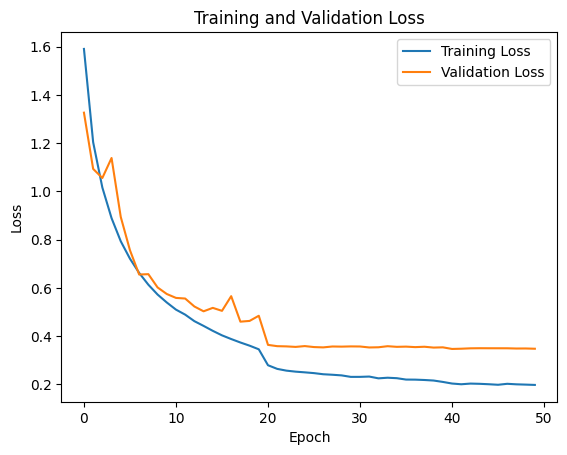

In [19]:
# Plotting training and validation loss
plt.plot(train_loss_list, label='Training Loss')
plt.plot(val_loss_list, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

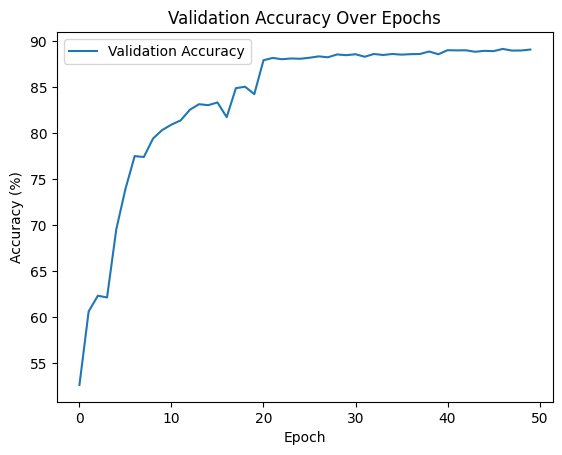

In [20]:
plt.plot(val_accuracy_list, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy Over Epochs')
plt.legend()
plt.show()

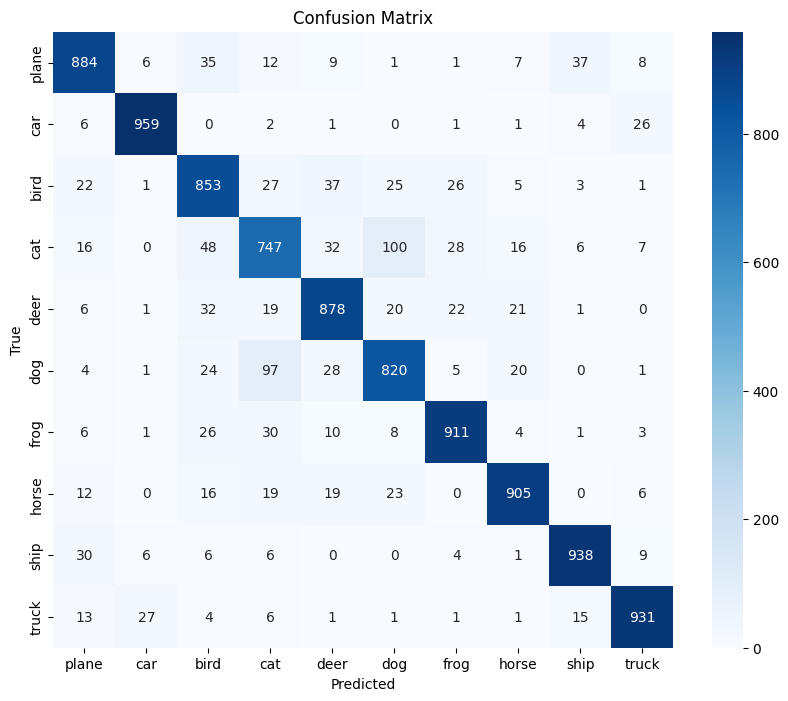

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_labels = []
all_predictions = []

net.eval() # Set model to evaluation mode
with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = net(images) # Use 'net' instead of 'model'
        _, predicted = torch.max(outputs.data, 1)
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

 Final Comparison

/tmp/ipykernel_1777/2772938183.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Test Accuracy (%)', y='Model', data=df_accuracy, palette='viridis')


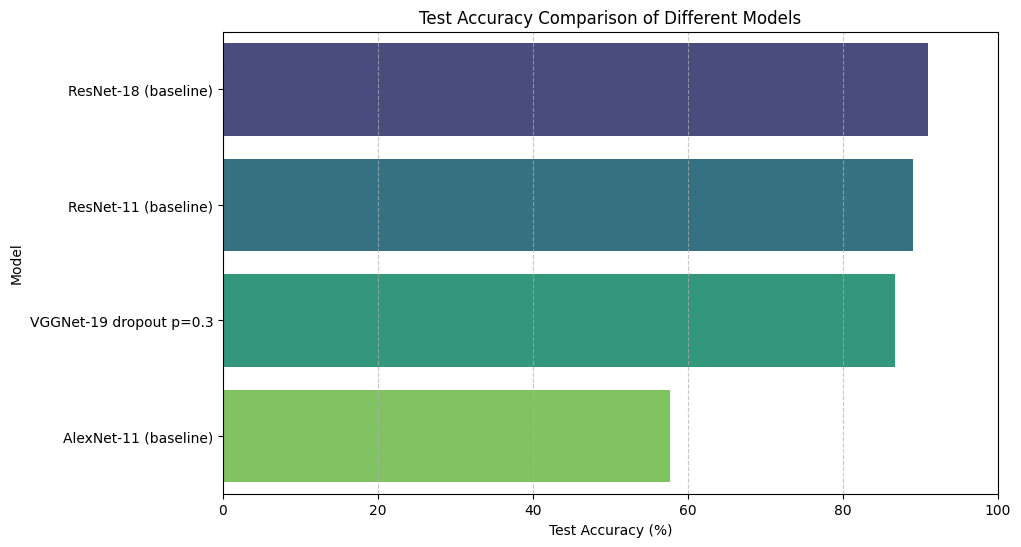

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data extracted from the user's request
models = [
    'AlexNet-11 (baseline)',
    'VGGNet-19 dropout p=0.3',
    'ResNet-11 (baseline)',
    'ResNet-18 (baseline)'
]

test_accuracies = [
    57.72,
    86.75,
    89.08,
    91.04
]

# Create a DataFrame for easier plotting
df_accuracy = pd.DataFrame({
    'Model': models,
    'Test Accuracy (%)': test_accuracies
})

# Sort by accuracy for better visualization
df_accuracy = df_accuracy.sort_values(by='Test Accuracy (%)', ascending=False)

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Test Accuracy (%)', y='Model', data=df_accuracy, palette='viridis')
plt.xlabel('Test Accuracy (%)')
plt.ylabel('Model')
plt.title('Test Accuracy Comparison of Different Models')
plt.xlim(0, 100) # Set x-axis limit from 0 to 100 for accuracy percentages
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()